In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from dataclasses import dataclass, field
from typing import Dict
import copy
from MediSpaAssumptions import MediAssumptions

MediSpaAssumptions = MediAssumptions()

In [3]:
def plot_dashboard(scenarios: dict):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle("MediSpa Bay Area — 36-Month Financial Forecast", fontsize=14, fontweight="bold")
    colors = {"Base": "#2196F3", "Bear": "#F44336", "Bull": "#4CAF50"}

    # 1. Revenue
    ax = axes[0, 0]
    for name, df in scenarios.items():
        ax.plot(df["Month"], df["Total_Revenue"] / 1000, label=name, color=colors[name])
    ax.set_title("Monthly Revenue")
    ax.set_ylabel("$K")
    ax.legend()
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:.0f}K"))

    # 2. Net Income
    ax = axes[0, 1]
    for name, df in scenarios.items():
        ax.plot(df["Month"], df["Net_Income"] / 1000, label=name, color=colors[name])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Monthly Net Income")
    ax.set_ylabel("$K")
    ax.legend()

    # 3. Cumulative Cash Flow
    ax = axes[1, 0]
    for name, df in scenarios.items():
        ax.plot(df["Month"], df["Cum_Cash_Flow"] / 1000, label=name, color=colors[name])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Cumulative Cash Flow (post-investment)")
    ax.set_ylabel("$K")
    ax.legend()

    # 4. ROI %
    ax = axes[1, 1]
    for name, df in scenarios.items():
        ax.plot(df["Month"], df["ROI_%"], label=name, color=colors[name])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title("Cumulative ROI %")
    ax.set_ylabel("%")
    ax.legend()

    plt.tight_layout()
    plt.savefig("medispa_forecast.png", dpi=150)
    plt.show()

In [4]:
def print_summary(scenarios: dict):
    total_investment = sum(MediSpaAssumptions.initial_investment.values())
    print(f"\n{'='*60}")
    print(f"  MEDISPA FORECAST SUMMARY  |  Total Investment: ${total_investment:,.0f}")
    print(f"{'='*60}")
    for name, df in scenarios.items():
        last = df.iloc[-1]
        breakeven = df[df["Cum_Cash_Flow"] >= 0]["Month"].min()
        print(f"\n  [{name} Case] — Month 36")
        print(f"    Monthly Revenue:    ${last['Total_Revenue']:>10,.0f}")
        print(f"    Monthly Net Income: ${last['Net_Income']:>10,.0f}")
        print(f"    Gross Margin:       {last['Gross_Margin_%']:>9.1f}%")
        print(f"    Cumulative ROI:     {last['ROI_%']:>9.1f}%")
        print(f"    Cash Breakeven:     Month {breakeven if pd.notna(breakeven) else '>36'}")
    print(f"\n{'='*60}\n")

In [5]:
scenarios = MediAssumptions().run_scenarios()

In [6]:
print_summary(scenarios)


  MEDISPA FORECAST SUMMARY  |  Total Investment: $5,000

  [Base Case] — Month 36
    Monthly Revenue:    $    17,260
    Monthly Net Income: $     3,234
    Gross Margin:            63.8%
    Cumulative ROI:        2004.8%
    Cash Breakeven:     Month 1

  [Bear Case] — Month 36
    Monthly Revenue:    $    11,682
    Monthly Net Income: $   -11,891
    Gross Margin:            63.4%
    Cumulative ROI:       -8863.0%
    Cash Breakeven:     Month >36

  [Bull Case] — Month 36
    Monthly Revenue:    $    23,197
    Monthly Net Income: $     5,746
    Gross Margin:            63.5%
    Cumulative ROI:        3704.3%
    Cash Breakeven:     Month 1




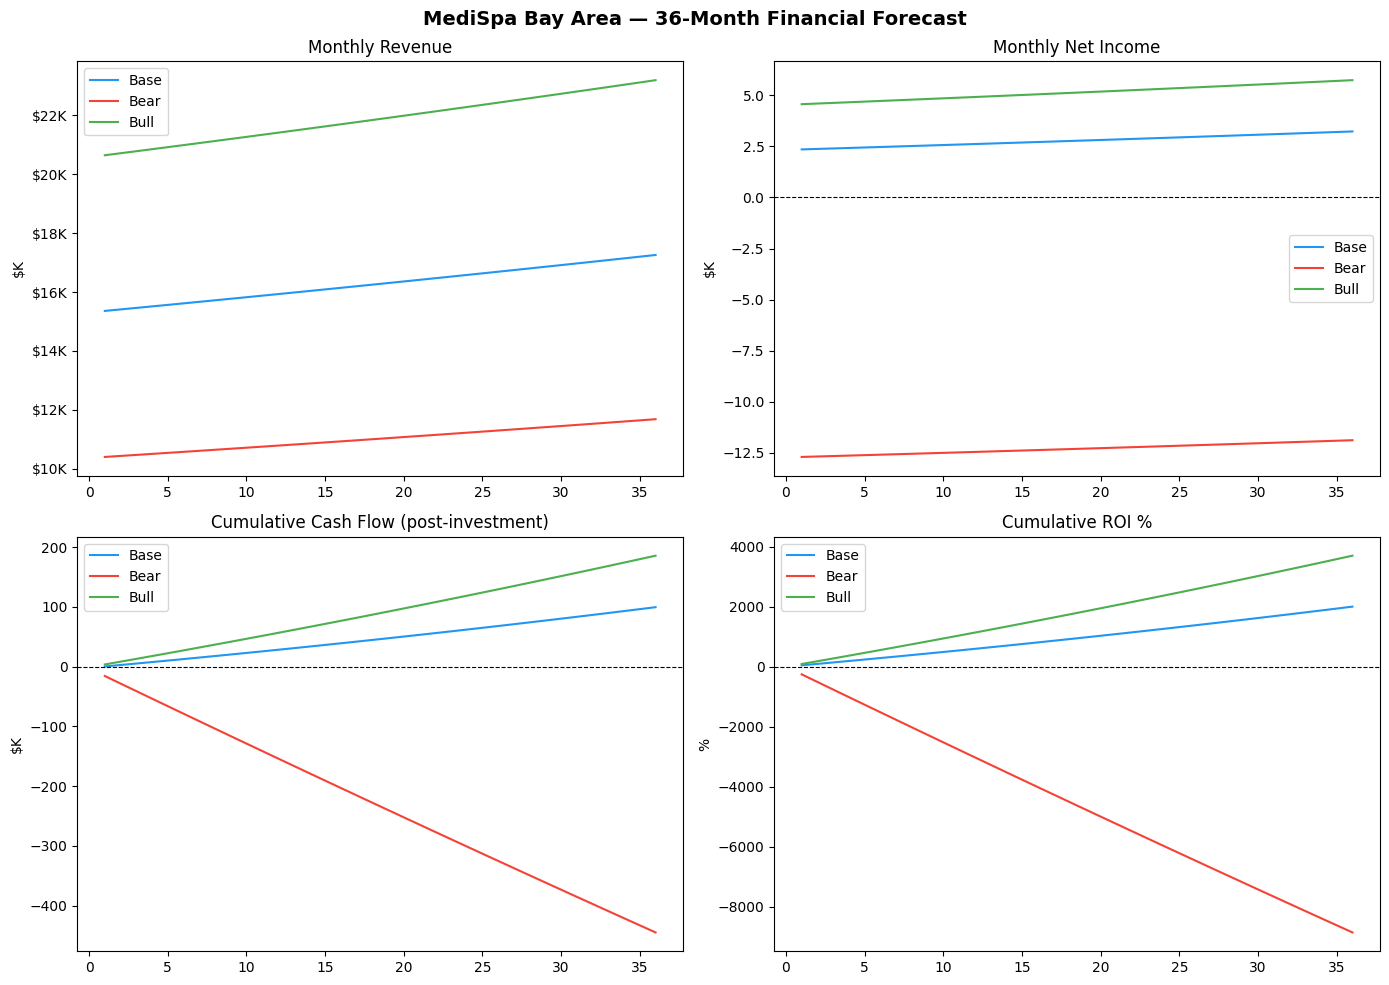

Exported to medispa_forecast.xlsx


In [7]:
plot_dashboard(scenarios)

# Export to Excel for further analysis
with pd.ExcelWriter("medispa_forecast.xlsx") as writer:
    for name, df in scenarios.items():
        df.to_excel(writer, sheet_name=name, index=False)
print("Exported to medispa_forecast.xlsx")